## Ví dụ A1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('SAT_GPA.csv') #Đọc file csv
data.describe() #Mô tả thuộc tính của dữ liệu (số bộ dữ liệu, trung bình, độ lệch chuẩn, min-max)

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


In [3]:
x = data['SAT']
y = data['GPA']
#Thuộc tính dữ liệu huấn luyện

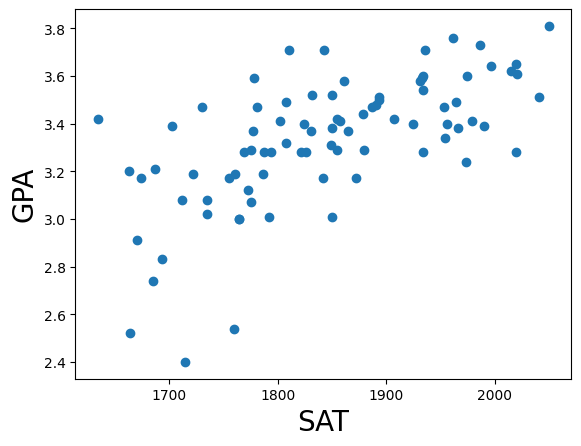

In [4]:
#Biểu đồ phân tán dữ liệu
plt.scatter(x, y)
plt.xlabel('SAT',  fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

In [1151]:
k = 8

#Tính khoảng cách giữa các điểm dữ liệu
def distance(array, value):
    array= np.array(array)
    return abs(array - value)

#Tìm tập k điểm gần nhất
def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

#Tính các độ đo MSE, MAE, R-squared
def print_measure(y_pred, y_true):
    print('MSE: ', np.mean((y_pred - y_true) ** 2))
    print('MAE: ', np.mean(np.abs(y_pred - y_true)))
    print('R - squared: ', 1 - (np.sum((y_pred - y_true) ** 2) / 
          np.sum((y_true - np.mean(y_true)) ** 2)))

In [1152]:
data_len = len(x)

#Tập training
X_train = np.array(x[:64])
Y_train = np.array(y[:64])

#Tập Valid
X_test = np.array(x[64:data_len])
Y_test = np.array(y[64:data_len])

k = 8
Y_predict = np.zeros(len(X_test)) #Khởi tạo đầu ra bằng 0

for i in range(len(X_test)):
    indexis = find_nearest_index(X_train, X_test[i], k)
    for id in indexis:
        Y_predict[i] = Y_predict[i] + Y_train[id]
    Y_predict[i] = Y_predict[i] / len(indexis)

df = pd.DataFrame({'Predict': Y_predict, 'True': Y_test})
print(df)
print_measure(Y_predict, Y_test)

    Predict  True
0   3.39250  3.51
1   3.27500  3.52
2   3.29500  3.52
3   3.39750  3.54
4   3.29500  3.58
5   3.39750  3.58
6   3.39750  3.59
7   3.25875  3.59
8   3.39000  3.60
9   3.39750  3.60
10  3.38750  3.61
11  3.38750  3.62
12  3.36625  3.64
13  3.38750  3.65
14  3.29500  3.71
15  3.39750  3.71
16  3.30875  3.71
17  3.36625  3.73
18  3.37625  3.76
19  3.38750  3.81
MSE:  0.08137789062500003
MAE:  0.2711875000000001
R - squared:  -10.951518670142466


## Ví dụ A2:

In [1153]:
from __future__ import division, print_function, unicode_literals

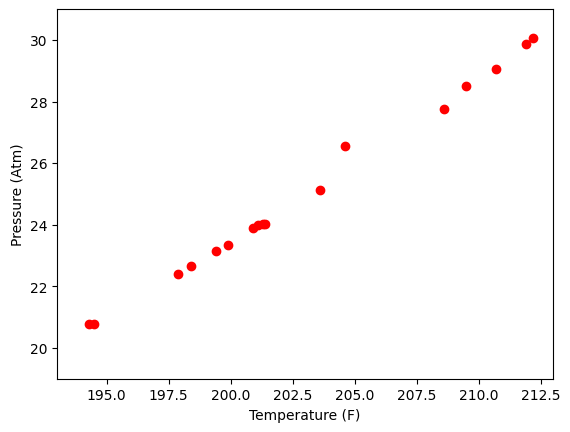

In [1154]:
#Nhiệt độ (đo bằng F)
X = np.array([[194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 201.1, 201.4, 201.3, 203.6,
               204.6, 209.5, 208.6, 210.7, 211.9, 212.2]]).T
#Áp suất (atm)
y = np.array([[20.79, 20.79, 22.4, 22.67, 23.15, 23.35, 23.89, 23.99, 24.02, 24.01, 25.14, 26.57,
               28.49, 27.76, 29.04, 29.88, 30.06]]).T
#Trực quan hóa dữ liệu
plt.plot(X, y, 'ro')
plt.axis([193, 213, 19, 31])
plt.xlabel('Temperature (F)')
plt.ylabel('Pressure (Atm)')
plt.show()

In [1155]:
k = 4
#Tính khoảng cách giữa các điểm dữ liệu
def distance(array, value):
    array= np.array(array)
    return abs(array - value)

#Tìm tập k điểm gần nhất
def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

#Tính các độ đo MSE, MAE, R-squared
def print_measure(y_pred, y_true):
    print('MSE: ', np.mean((y_pred - y_true) ** 2))
    print('MAE: ', np.mean(np.abs(y_pred - y_true)))
    print('R - squared: ', 1 - (np.sum((y_pred - y_true) ** 2) / 
          np.sum((y_true - np.mean(y_true)) ** 2)))

data_len = len(X)

#Tập training
X_train = np.array(X[:16])
y_train = np.array(y[:16])

#Tập validation
X_valid = np.array(X[16:data_len])
y_valid = np.array(y[16:data_len])

#Khởi tạo đầu ra
Y_predict = np.zeros(len(X_valid))

for i in range(len(X_valid)):
    indexes = find_nearest_index(X_train, X_valid[i], k)
    for id in indexes:
        Y_predict[i] = Y_predict[i] + y_train[id]
    Y_predict[i] = Y_predict[i] / len(indexes)

df = pd.DataFrame({'Predict': Y_predict, 'True': y_valid.flatten()})
print(df)
print_measure(Y_predict, Y_test)

   Predict   True
0    20.79  30.06
MSE:  294.50672999999995
MAE:  17.161
R - squared:  -43251.56719048319


/tmp/ipykernel_2880/3720632832.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_predict[i] = Y_predict[i] + y_train[id]


## Ví dụ A3

In [1156]:
import math

with open('fuel.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]
    dlic = 1000 * splitted[0] / splitted[5]
    logMiles = math.log2(splitted[3])
    y_data.append([fuel])
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])

x_data = np.asarray(x_data)
y_data = np.asarray(y_data)

In [1157]:
k = 6

def distance(array, value):
    array = np.array(array)
    return np.linalg.norm(array - value, ord = 2, axis = 1)

def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

def print_measure(y_pred, y_true):
    print('MSE: ', np.mean((y_pred - y_true) ** 2))
    print('MAE: ', np.mean(np.abs(y_pred - y_true)))
    print('R - squared: ', 1 - (np.sum((y_pred - y_true) ** 2) / 
          np.sum((y_true - np.mean(y_true)) ** 2)))

data_len = len(x_data)

#Tập training
x_train = np.array(x_data[:40])
y_train = np.array(y_data[:40])

#Tập Valid
x_valid = np.array(x_data[40:data_len])
y_valid = np.array(y_data[40:data_len])

y_predict = np.zeros(len(x_valid)) #Khởi tạo đầu ra bằng 0

for i in range(len(x_valid)):
    indexis = find_nearest_index(x_train, x_valid[i], k)
    for id in indexis:
        y_predict[i] += y_train[id]
    y_predict[i] /= len(indexis)

df = pd.DataFrame({'Predict': y_predict, 'True': y_valid.flatten()})
print(df)
print_measure(y_predict, y_valid.flatten())

       Predict        True
0   655.902951  711.733058
1   638.456058  697.052777
2   638.456058  638.231061
3   611.926991  681.100137
4   655.902951  591.499946
5   644.489829  691.022712
6   588.044468  681.031121
7   605.099850  576.069750
8   662.653140  562.410933
9   584.952429  581.793717
10  644.489829  842.791752
MSE:  6956.363785903602
MAE:  65.31640461096231
R - squared:  -0.13937316912292097


/tmp/ipykernel_2880/1248247894.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_predict[i] += y_train[id]


## Ví dụ B1

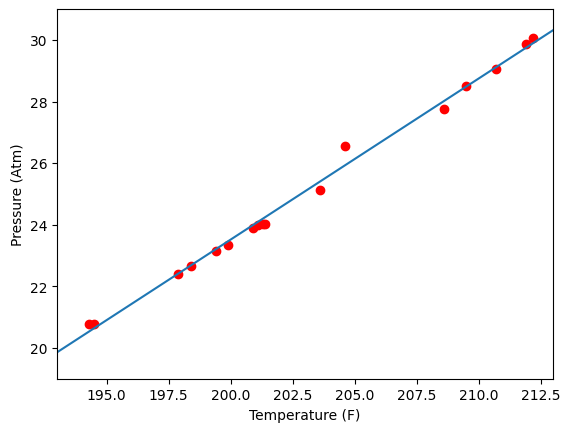

In [1158]:
#Nhiệt độ (đo bằng F)
X = np.array([[194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 201.1, 201.4, 201.3, 203.6,
               204.6, 209.5, 208.6, 210.7, 211.9, 212.2]]).T
#Áp suất (atm)
y = np.array([[20.79, 20.79, 22.4, 22.67, 23.15, 23.35, 23.89, 23.99, 24.02, 24.01, 25.14, 26.57,
               28.49, 27.76, 29.04, 29.88, 30.06]]).T

#Xây dựng cột X
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

#Tính các trọng số của phương trình hồi quy tuyến tính
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)

w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(193, 213, 2)
y0 = w_0 + w_1 * x0

#Vẽ đường thẳng hồi quy
plt.plot(X.T, y.T, 'ro')
plt.plot(x0, y0)
plt.axis([193, 213, 19, 31])
plt.xlabel('Temperature (F)')
plt.ylabel('Pressure (Atm)')
plt.show()

## Ví dụ B2

* Đọc dữ liệu từ tệp

In [1159]:
import math
import numpy as np

with open('fuel.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]
    dlic = 1000 * splitted[0] / splitted[5]
    logMiles = math.log2(splitted[3])
    y_data.append([fuel])
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])

x_data = np.asarray(x_data)
y_data = np.asarray(y_data)

a) Trường hợp sử dụng Numpy

In [1160]:
#Dùng thuật toán HouseHolder để khai triển QR
def qr_householder(A):
    M = A.shape[0]
    N = A.shape[1]

    #Khởi tạo Q là ma trận đơn vị
    Q = np.identity(M)

    #Khởi tạo R là ma trận không
    R = np.copy(A)

    for n in range(N):
        x = A[n:, n]
        k = x.shape[0]

        ro = -np.sign(x[0]) * np.linalg.norm(x)

        e = np.zeros(k)
        e[0] = 1
        v = (1 / (x[0] - ro)) * (x - (ro * e))

        for i in range(N):
            R[n:, i] = R[n:, i] - (2 / (v@v)) * ((np.outer(v, v)) @ R[n:, i])

        for i in range(M):
            Q[n:, i] = Q[n:, i] - (2 / (v@v)) * ((np.outer(v, v)) @ Q[n:, i])

    return Q.transpose(), R

def linear_regression(x_data, y_data):
    x_bars = np.concatenate((np.ones((x_data.shape[0], 1)), x_data), axis = 1)

    Q, R = qr_householder(x_bars)
    R_pinv = np.linalg.pinv(R)
    A = np.dot(R_pinv, Q.T)

    return np.dot(A, y_data)

In [1161]:
w = linear_regression(x_data, y_data)
w = w.T.tolist()
line = ['Intercept', 'Tax', 'Dlic', 'Income', 'LogMiles']
res = list(zip(line, w[0]))
for o in res:
    print("{: >20}: {: >10}".format(*o))

           Intercept: 154.19284457730845
                 Tax: -4.227983208329615
                Dlic: 0.4718712134419839
              Income: -0.006135330970417756
            LogMiles: 18.545274506048013


b) Trường hợp sử dụng thư viện Scikit-learn

In [1162]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Xây dựng mô hình hồi quy tuyến tính
model = LinearRegression()
model.fit(x_data, y_data)

# Lấy các tham số hồi quy
intercept = model.intercept_.ravel()
coefficients = model.coef_.ravel()

res = np.concatenate((intercept, coefficients))

for name, value in zip(['Intercept', 'Tax', 'Dlic', 'Income', 'LogMiles'], res):
    print(f"{name:>20}: {value:>10}")

           Intercept: 154.1928445773048
                 Tax: -4.227983208329685
                Dlic: 0.4718712134419861
              Income: -0.0061353309704177406
            LogMiles: 18.545274506048024


## Bài tập B1

In [1163]:
#Tập training
x_train = np.array(x_data[:40])
y_train = np.array(y_data[:40])

#Tập validation
x_valid = np.array(x_data[40:])
y_valid = np.array(y_data[40:])

#Dự đoán đầu ra
y_train_pred = model.predict(x_train)
y_valid_pred = model.predict(x_valid)

df = pd.DataFrame({'Predict': y_valid_pred.flatten(), 'True': y_valid.flatten()})
df.index = df.index + 1
print(df)

       Predict        True
1   666.001135  711.733058
2   649.575323  697.052777
3   657.729032  638.231061
4   630.279521  681.100137
5   630.453962  591.499946
6   667.961262  691.022712
7   607.702966  681.031121
8   605.146291  576.069750
9   619.709317  562.410933
10  593.122318  581.793717
11  659.292991  842.791752


* Độ đo MSE, MAE, R2 dựa trên tập training và tập validation

In [1164]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_valid = mean_squared_error(y_valid, y_valid_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_valid = mean_absolute_error(y_valid, y_valid_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_valid = r2_score(y_valid, y_valid_pred)

print("TRAINING SET")
print("MSE :", mse_train)
print("MAE :", mae_train)
print("R2  :", r2_train)

print("\nVALIDATION SET")
print("MSE :", mse_valid)
print("MAE :", mae_valid)
print("R2  :", r2_valid)

TRAINING SET
MSE : 3525.916131951754
MAE : 44.47151308039231
R2  : 0.5272755291573563

VALIDATION SET
MSE : 4787.579081043686
MAE : 52.73398823301322
R2  : 0.2158490674324639


## Ví dụ B3

* Đọc dữ liệu đầu vào

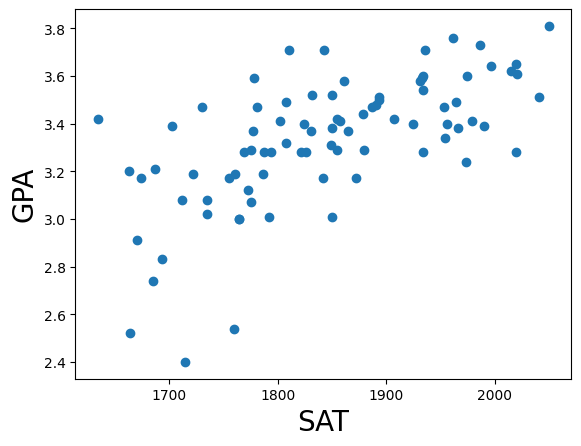

In [1165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv("SAT_GPA.csv")
data.describe()

y = data['GPA']
x = data['SAT']

plt.scatter(x,y)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

In [1166]:
data_len = len(x)

x = x.to_numpy().reshape(-1, 1)
y = y.to_numpy().ravel()  

#Tập training
X_train = np.array(x[:64])
Y_train = np.array(y[:64])

#Tập validation
X_test = np.array(x[64:data_len])
Y_test = np.array(y[64:data_len])

#Xây dựng mô hình hồi quy tuyến tính
model = LinearRegression()
model.fit(X_train, Y_train)

#Đầu ra
Y_pred = model.predict(X_test)

#Các hệ số
intercept = model.intercept_.ravel()
coefficients = model.coef_ .ravel()

res = np.concatenate((intercept, coefficients))

for name, value in zip(['Intercept', 'SAT'], res):
    print(f"{name:}: {value:}")
        
#Độ đo MSE, MAE, R2
MSE = mean_squared_error(Y_test, Y_pred)
MAE = mean_absolute_error(Y_test, Y_pred)
R2 = r2_score(Y_test, Y_pred)
        
print(f"MSE: {MSE}")
print(f"MAE: {MAE}")
print(f"R_square: {R2}")

Intercept: 0.8382097630766756
SAT: 0.0013183893573835055
MSE: 0.07263824293181359
MAE: 0.24880371695218736
R_square: -9.667975169894788


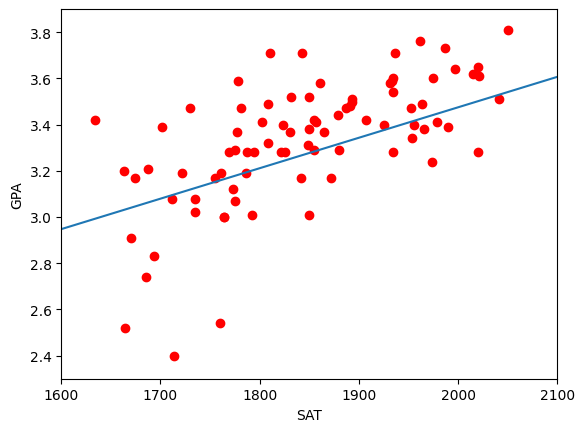

In [1167]:
t_0 = intercept
t_1 = coefficients[0]
x0 = np.linspace(1600, 2100, 2)
y0 = t_1 * x0 + t_0

plt.plot(x, y, 'ro')
plt.plot(x0, y0)
plt.axis([1600, 2100, 2.3, 3.9])
plt.xlabel('SAT')
plt.ylabel('GPA')
plt.show()

## Ví dụ B4

* Đọc dữ liệu đầu vào

In [1168]:
import numpy as np
from sklearn.linear_model import LinearRegression

with open('vidu4_lin_reg.txt') as f:
    lines = f.readlines()

data = []
for line in lines[1:]:
    values = [float(x) for x in line.split()[1:]]
    data.append(values)
data_array = np.array(data)

x_data = data_array[:, 0:5]
y_data = data_array[:, 5]

In [1169]:
data_len = len(data_array)

#Tập training
X_train = np.array(x_data[:80])
Y_train = np.array(y_data[:80])

#Tập validation
X_test = np.array(x_data[80:])
Y_test = np.array(y_data[80:])

#Xây dựng mô hình hồi quy tuyến tính
model = LinearRegression()
model.fit(X_train, Y_train)

#Đầu ra
Y_pred = model.predict(X_test)

#Các hệ số
intercept = model.intercept_.ravel()
coefficients = model.coef_ .ravel()
print(coefficients)

res = np.concatenate((intercept, coefficients))
for name, value in zip(['Intercept', 'Tuổi', 'BMI', 'Huyết áp tâm thu', 'Glucose', 'Cholesterol'], res):
    print(f"{name:}: {value:}")

#Phần dư
residuals = Y_test - Y_pred

# Tính kỳ vọng của sai số
mean_residuals = np.mean(residuals)

# Tính phương sai của sai số
variance_residuals = np.var(residuals)

print(f"Kỳ vọng của sai số là: {mean_residuals}")
print(f"Phương sai của sai số là: {variance_residuals}")

[ 0.0089892  -0.00047742  0.00260218  0.00808634  0.00708535]
Intercept: 0.04306436410329684
Tuổi: 0.008989196889296787
BMI: -0.0004774242218527432
Huyết áp tâm thu: 0.0026021798675557755
Glucose: 0.008086342231978155
Cholesterol: 0.007085352341923756
Kỳ vọng của sai số là: 0.0799886169619709
Phương sai của sai số là: 0.22100281283267012


## Ví dụ B5

* Đọc dữ liệu đầu vào

In [1170]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

with open('real_estate.csv') as f:
    lines = f.readlines()

data = []
for line in lines[1:]:
    values = [float(x) for x in line.strip().split(',')]
    data.append(values)
data_array = np.array(data)

x_data = data_array[:, 0:6]
y_data = data_array[:, 6]

In [1171]:
#Tập training
x_train = x_data[:350]
y_train = y_data[:350]

#Tập Validation
x_valid = x_data[350:]
y_valid = y_data[350:]

#Mô hình hồi quy tuyến tính
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_1 = model.predict(x_valid) #Đầu ra
sse_1 = np.sum((y_valid - y_pred_1) ** 2) #SSE mô hình hồi quy tuyến tính
print(f"SSE Hồi quy tuyến tính: {sse_1}")

#Mô hình K-NN
knn = KNeighborsRegressor(n_neighbors=18)
knn.fit(x_train, y_train)
y_pred_2 = knn.predict(x_valid) #Đầu ra
sse_2 = np.sum((y_valid - y_pred_2) ** 2) #SSE mô hình K-NN
print(f"SSE K-NN (K=18): {sse_2}")

SSE Hồi quy tuyến tính: 0.007554520719836415
SSE K-NN (K=18): 0.007711798317902722
